# Pronóstico de Precipitación Mensual para Planificación Agrícola
## Modelos SARIMAX en Series de Tiempo Ambientales

### Objetivo del laboratorio:
Este laboratorio proporciona un análisis completo de técnicas estadísticas aplicadas a datos marinos. Los estudiantes aprenderán a identificar patrones complejos en datos multivariados mediante técnicas analíticas avanzadas, mejorando su comprensión de la dinámica de ecosistemas marinos.

### Objetivos de aprendizaje:
- Analizar autocorrelación (ACF) y autocorrelación parcial (PACF) en series de tiempo
- Aplicar modelos SARIMAX para pronóstico de series temporales
- Calcular métricas de precisión del modelo (RMSE, MAE)
- Interpretar parámetros SARIMAX (p,d,q)(P,D,Q,s) en el contexto de datos ambientales
- Realizar diagnósticos residuales para validación del modelo

### Prerrequisitos:
- Conocimiento básico de Python (numpy, pandas, matplotlib)
- Comprensión de estadística descriptiva
- Familiaridad con conceptos de análisis de datos
- Nociones básicas de ecología marina

### Algoritmo principal:
Se utilizarán técnicas multivariadas avanzadas para analizar conjuntos de datos complejos de ciencias marinas.

### Duración estimada:
60-90 minutos

---


Case Use: Forecasting Monthly Rainfall for Agricultural Planning
Problem Description:
Agricultural scientists are interested in forecasting monthly rainfall to aid in crop planning and management strategies. Accurate predictions of rainfall patterns can significantly affect the efficiency of water usage and crop yields in agricultural sectors.

Statistical Technique:
Time Series Analysis, particularly using Seasonal ARIMA (AutoRegressive Integrated Moving Average) models, which is effective for handling data with trends, cycles, and seasonal variations.

Hypothesis:
The hypothesis is that rainfall has clear seasonal patterns that can be effectively forecasted using historical monthly rainfall data.

Dataset Description:
The dataset is a synthetic time series representing monthly rainfall over a 20-year period.

Student Task:
Students are tasked with using the provided Seasonal ARIMA model code to forecast future monthly rainfall. Adjustments and tasks include:

Performing a seasonal decomposition to confirm the presence of seasonality.
Fitting a Seasonal ARIMA model to the historical data.
Forecasting rainfall for the next 24 months.
Evaluating the model's performance and interpreting the results.

RAINFALL FORECASTING: Time Series Analysis for Agricultural Planning

Data Summary:
Time period: 2000-01 to 2019-12
Total observations: 240
Mean rainfall: 49.99 mm
Std deviation: 8.19 mm

--------------------------------------------------------------------------------
STEP 1: SEASONAL DECOMPOSITION
--------------------------------------------------------------------------------
Decomposing time series into Trend, Seasonal, and Residual components...



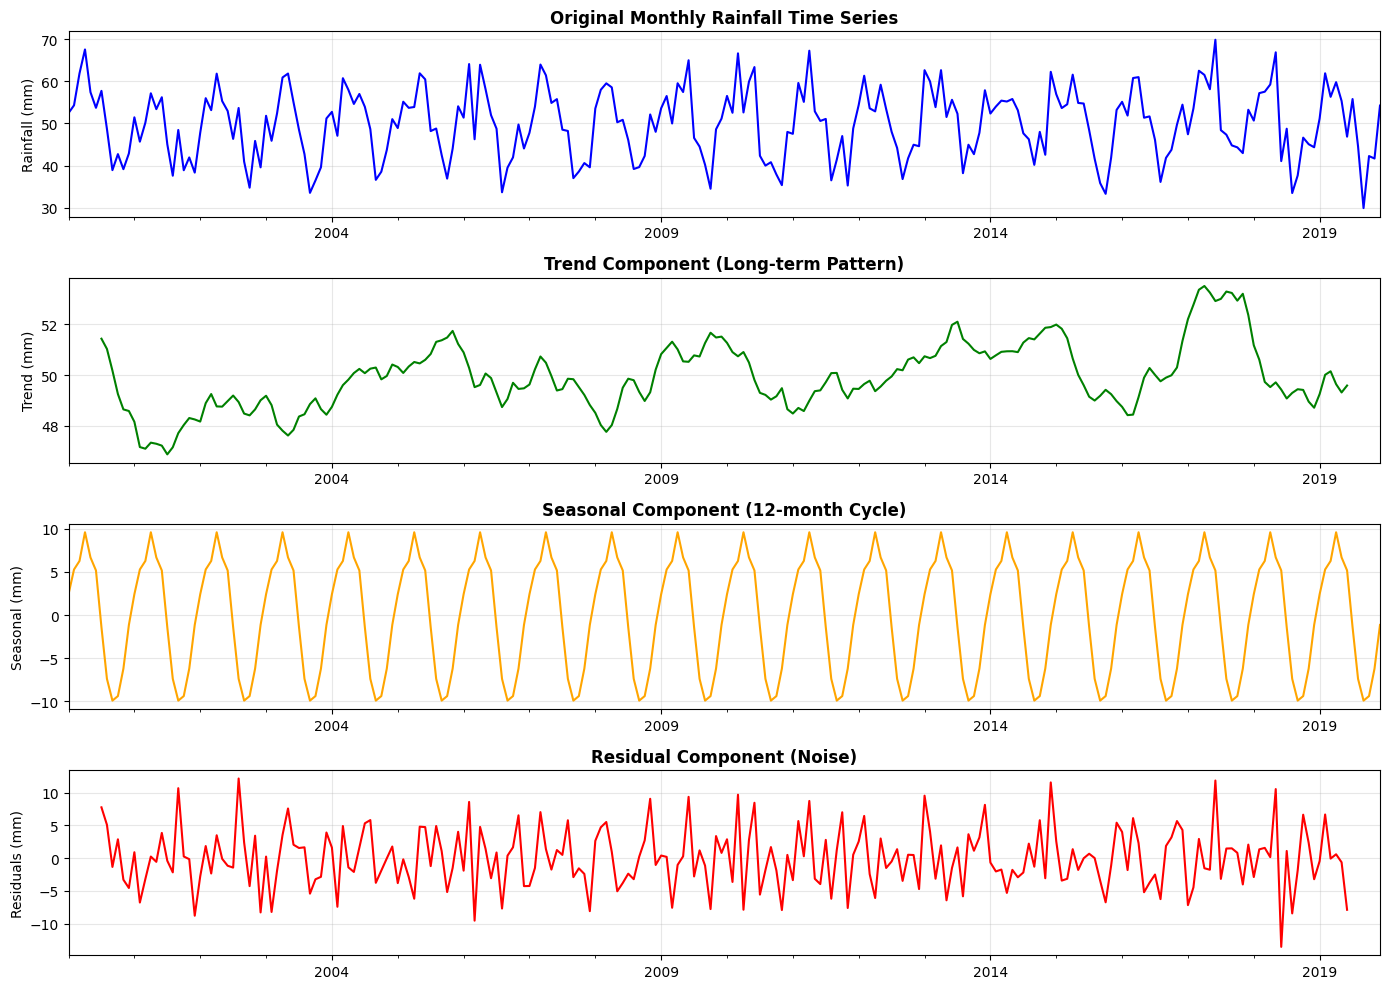

--------------------------------------------------------------------------------
STEP 2: ACF AND PACF ANALYSIS
--------------------------------------------------------------------------------
ACF (AutoCorrelation Function): Measures correlation of observations at different lags
PACF (Partial ACF): Shows correlation after removing intermediate lags



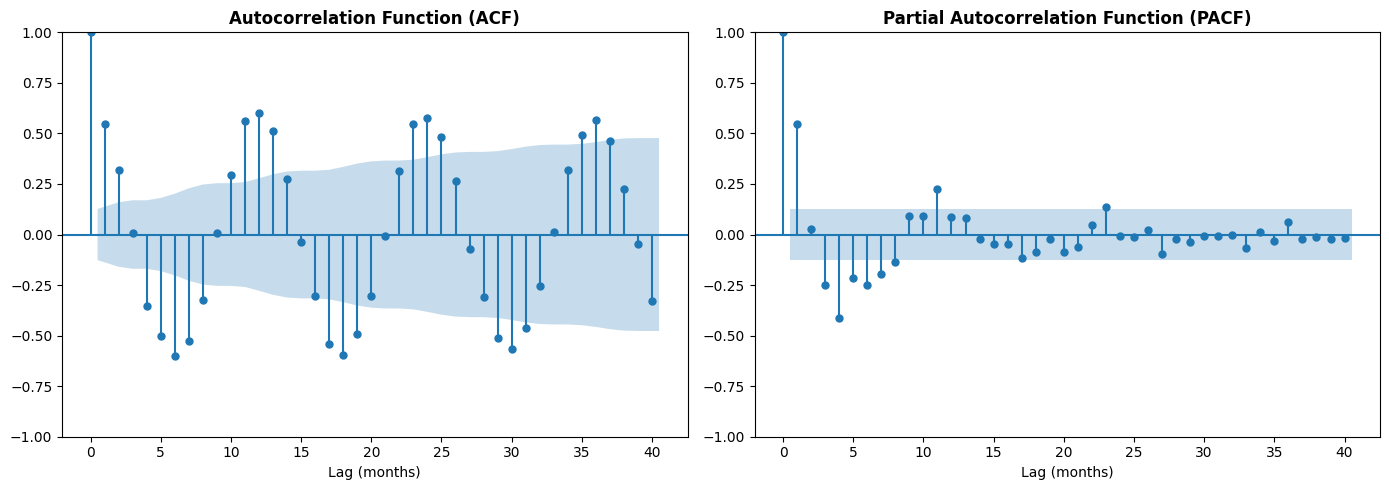

--------------------------------------------------------------------------------
STEP 3: SARIMAX MODEL PARAMETERS
--------------------------------------------------------------------------------
SARIMAX(p,d,q)(P,D,Q,s) where:
  Non-Seasonal: (p,d,q)
    p = Number of autoregressive terms (AR)
    d = Number of differencing operations (I)
    q = Number of moving average terms (MA)
  Seasonal: (P,D,Q,s)
    P = Seasonal autoregressive terms
    D = Seasonal differencing
    Q = Seasonal moving average terms
    s = Seasonal period (12 for monthly data)

Model chosen: SARIMAX(1,1,1)(1,1,1,12)
  - 1 lag of AR, 1 differencing, 1 lag of MA (non-seasonal)
  - 1 seasonal AR, 1 seasonal diff, 1 seasonal MA with 12-month period

--------------------------------------------------------------------------------
STEP 4: MODEL FITTING
--------------------------------------------------------------------------------


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  240
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -701.934
Date:                            Mon, 06 Apr 2026   AIC                           1413.867
Time:                                    17:03:27   BIC                           1430.992
Sample:                                01-31-2000   HQIC                          1420.777
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0486      0.085     -0.572      0.567      -0.215       0.118
ma.L1         -0.9998      4.804   

Test Period: 2018-01 to 2019-12
Root Mean Square Error (RMSE): 6.2466 mm
Mean Absolute Error (MAE): 4.4690 mm
Mean Absolute Percentage Error (MAPE): 9.02%



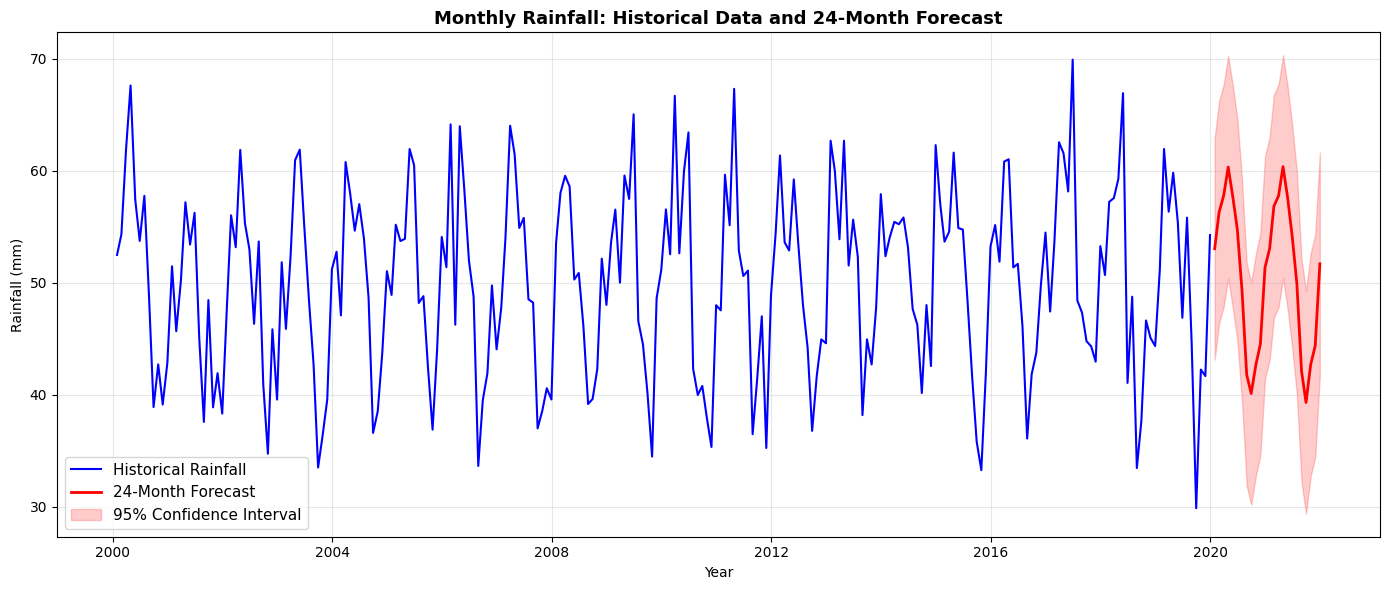

Forecast completed successfully!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas.plotting import register_matplotlib_converters
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

register_matplotlib_converters()

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
n_periods = 240  # 20 years of monthly data
time_index = pd.date_range(start='2000-01-01', periods=n_periods, freq='M')
# Seasonal rainfall pattern with trend and noise
rainfall = 50 + 10*np.sin(np.linspace(0, 40*np.pi, n_periods)) + np.random.normal(size=n_periods, scale=5)
data = pd.Series(rainfall, index=time_index)

print("=" * 80)
print("RAINFALL FORECASTING: Time Series Analysis for Agricultural Planning")
print("=" * 80)
print()

print("Data Summary:")
print(f"Time period: {data.index[0].strftime('%Y-%m')} to {data.index[-1].strftime('%Y-%m')}")
print(f"Total observations: {len(data)}")
print(f"Mean rainfall: {data.mean():.2f} mm")
print(f"Std deviation: {data.std():.2f} mm")
print()

# Step 1: Seasonal decomposition
print("-" * 80)
print("STEP 1: SEASONAL DECOMPOSITION")
print("-" * 80)
print("Decomposing time series into Trend, Seasonal, and Residual components...")
print()

result = seasonal_decompose(data, model='additive', period=12)  # 12-month seasonality

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
# Original time series
data.plot(ax=axes[0], color='blue')
axes[0].set_title('Original Monthly Rainfall Time Series', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rainfall (mm)')
axes[0].grid(True, alpha=0.3)

# Trend component
result.trend.plot(ax=axes[1], color='green')
axes[1].set_title('Trend Component (Long-term Pattern)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Trend (mm)')
axes[1].grid(True, alpha=0.3)

# Seasonal component
result.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_title('Seasonal Component (12-month Cycle)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal (mm)')
axes[2].grid(True, alpha=0.3)

# Residual component
result.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residual Component (Noise)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residuals (mm)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 2: ACF and PACF plots
print("-" * 80)
print("STEP 2: ACF AND PACF ANALYSIS")
print("-" * 80)
print("ACF (AutoCorrelation Function): Measures correlation of observations at different lags")
print("PACF (Partial ACF): Shows correlation after removing intermediate lags")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot
plot_acf(data, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (months)')

# PACF plot
plot_pacf(data, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (months)')

plt.tight_layout()
plt.show()

# Step 3: SARIMAX Model Explanation
print("-" * 80)
print("STEP 3: SARIMAX MODEL PARAMETERS")
print("-" * 80)
print("SARIMAX(p,d,q)(P,D,Q,s) where:")
print("  Non-Seasonal: (p,d,q)")
print("    p = Number of autoregressive terms (AR)")
print("    d = Number of differencing operations (I)")
print("    q = Number of moving average terms (MA)")
print("  Seasonal: (P,D,Q,s)")
print("    P = Seasonal autoregressive terms")
print("    D = Seasonal differencing")
print("    Q = Seasonal moving average terms")
print("    s = Seasonal period (12 for monthly data)")
print()
print("Model chosen: SARIMAX(1,1,1)(1,1,1,12)")
print("  - 1 lag of AR, 1 differencing, 1 lag of MA (non-seasonal)")
print("  - 1 seasonal AR, 1 seasonal diff, 1 seasonal MA with 12-month period")
print()

# Step 4: Fit SARIMAX model
print("-" * 80)
print("STEP 4: MODEL FITTING")
print("-" * 80)

model = SARIMAX(data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
fit_model = model.fit(disp=False)

print(fit_model.summary())
print()

# Step 5: Forecasting
print("-" * 80)
print("STEP 5: FORECASTING AND ACCURACY METRICS")
print("-" * 80)

# Split data into train/test
train_data = data[:216]  # First 18 years
test_data = data[216:]   # Last 2 years

# Refit model on training data
train_model = SARIMAX(train_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
train_fit = train_model.fit(disp=False)

# Forecast on test period
forecast_result = train_fit.get_forecast(steps=len(test_data))
forecast_values = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# Calculate accuracy metrics
rmse = np.sqrt(mean_squared_error(test_data, forecast_values))
mae = mean_absolute_error(test_data, forecast_values)

print(f"Test Period: {test_data.index[0].strftime('%Y-%m')} to {test_data.index[-1].strftime('%Y-%m')}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f} mm")
print(f"Mean Absolute Error (MAE): {mae:.4f} mm")
print(f"Mean Absolute Percentage Error (MAPE): {(mae/test_data.mean()*100):.2f}%")
print()

# Forecast next 24 months
forecast_24 = fit_model.get_forecast(steps=24)
forecast_index = pd.date_range(start=data.index[-1], periods=25, freq='M')[1:]
forecast_df = pd.Series(forecast_24.predicted_mean, index=forecast_index)
forecast_ci_24 = forecast_24.conf_int()

# Plot results
plt.figure(figsize=(14, 6))
plt.plot(data, label='Historical Rainfall', color='blue', linewidth=1.5)
plt.plot(forecast_df, label='24-Month Forecast', color='red', linewidth=2)
plt.fill_between(forecast_ci_24.index, 
                 forecast_ci_24.iloc[:, 0], 
                 forecast_ci_24.iloc[:, 1], 
                 color='red', alpha=0.2, label='95% Confidence Interval')
plt.title('Monthly Rainfall: Historical Data and 24-Month Forecast', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Forecast completed successfully!")


Instructions

Run the provided code to analyze the initial time series and decomposition results.
Adjust the SARIMAX parameters based on the ACF and PACF plots if needed (not included in the provided code, students should add this to confirm the model parameters).
Interpret the summary to understand the significance of the model coefficients.
Evaluate the accuracy of the forecasts and discuss potential implications for agricultural planning.
This case provides a hands-on application of time series forecasting, enabling students to explore how statistical techniques can be utilized in practical scenarios such as agriculture.

## Ejercicios para el Estudiante

### Ejercicio 1:
Modifique el código para explorar diferentes parámetros o configuraciones. Documente cómo cambian los resultados y explique por qué.

### Ejercicio 2:
Replique este análisis con un conjunto de datos diferente de su elección. Discuta las similitudes y diferencias en los resultados.

### Ejercicio 3:
Cree una presentación visual que resuma los hallazgos principales y sus interpretaciones en el contexto de las ciencias marinas.
